### Import and load

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [106]:
# load dataset
df = pd.read_csv("data.csv", encoding="ISO-8859-1")

# show first 10 rows
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


### Data cleaning

In [107]:
# remove missing CustomerID
df = df.dropna(subset=["CustomerID"])

# convert date
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# remove negative or zero values
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# create revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

### Overview

In [108]:
total_revenue = df["Revenue"].sum()
num_customers = df["CustomerID"].nunique()
num_orders = df["InvoiceNo"].nunique()
num_countries = df["Country"].nunique()

# print
print("Total revenue:", round(total_revenue, 2))
print("Total number of customers:", num_customers)
print("Total number of orders:", num_orders)
print("Total number of countries:", num_countries)

Total revenue: 8911407.9
Total number of customers: 4338
Total number of orders: 18532
Total number of countries: 37


### Top 10 countries by revenue

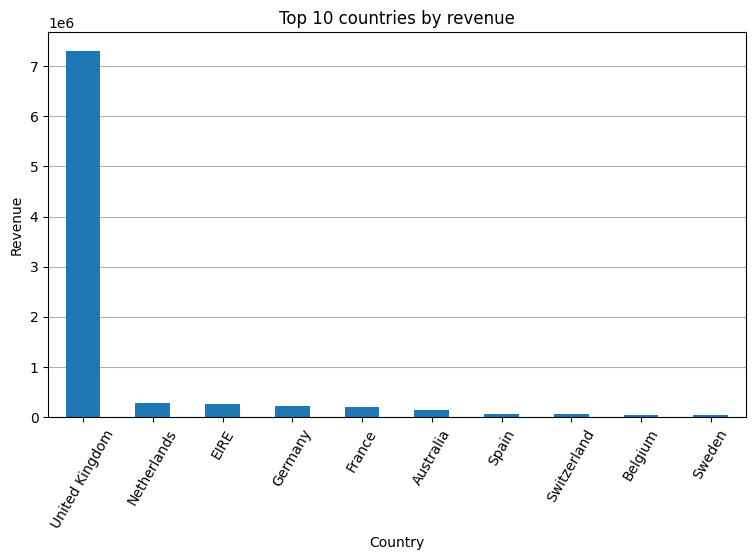

In [109]:
revenue_by_country = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
top_countries = revenue_by_country.head(10)

# plot
top_countries.plot(kind="bar", figsize=(9,5)).set_axisbelow(True)
plt.title("Top 10 countries by revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=60)
plt.grid(axis='y')
plt.show()

### Orders per customer distribution

Min orders per customer: 1
Max orders per customer: 209


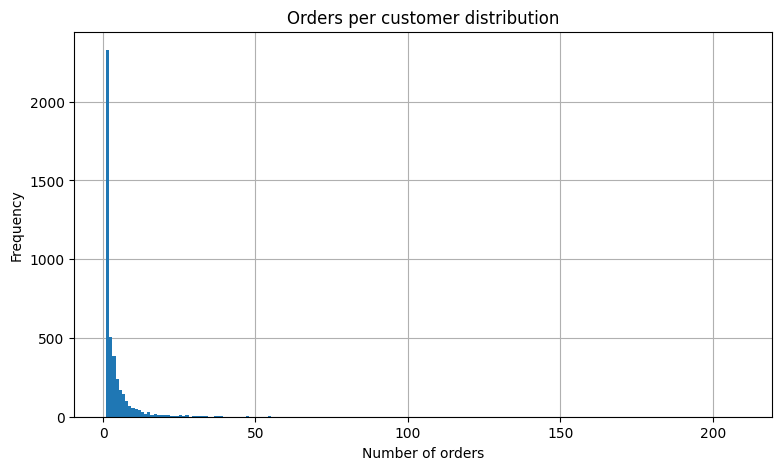

In [110]:
orders_per_customer = df.groupby("CustomerID")["InvoiceNo"].nunique()

# print
print("Min orders per customer:", orders_per_customer.min())
print("Max orders per customer:", orders_per_customer.max())

# plot
orders_per_customer.hist(bins=200, figsize=(9,5)).set_axisbelow(True)
plt.title("Orders per customer distribution")
plt.xlabel("Number of orders")
plt.ylabel("Frequency")
plt.show()

### Top customers

In [111]:
top_customers = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(15)

# print
print(top_customers)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
16684.0     66653.56
14096.0     65164.79
13694.0     65039.62
15311.0     60767.90
13089.0     58825.83
Name: Revenue, dtype: float64

### Montly revenue

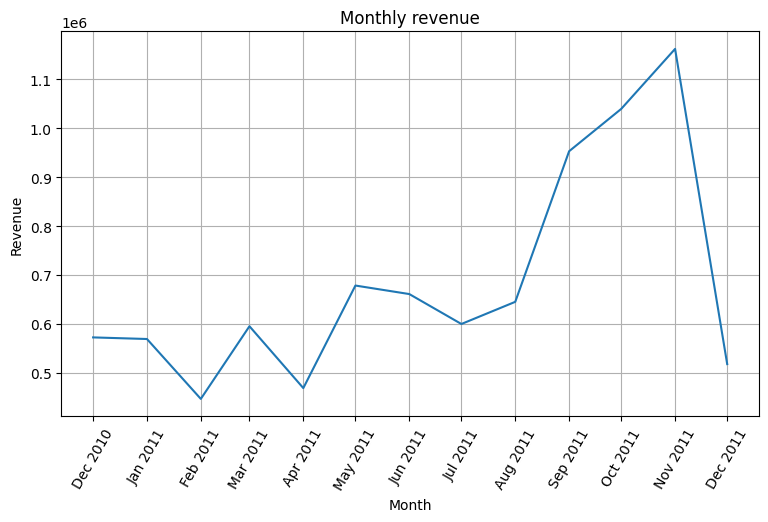

In [112]:
df["Month"] = df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
monthly_revenue = df.groupby("Month")["Revenue"].sum()

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(monthly_revenue.index, monthly_revenue.values)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.title("Monthly revenue")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.xticks(rotation=60)
plt.grid(True)
plt.show()